# Dihedrals decomposition of the folded basin

In [50]:
%load_ext autoreload
%autoreload 2 

data_folder = "../data/"

import numpy as np
import pandas as pd

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.linewidth": 0.9,
    "xtick.major.width": 0.9,
    "ytick.major.width": 0.9,
    "xtick.minor.width": 0.7,
    "ytick.minor.width": 0.7,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import LogLocator
import plotting_utils as pu
from matplotlib.patches import Patch
from matplotlib import color_sequences
from matplotlib.colors import TwoSlopeNorm

#import networkx as nx # graph visualization of MSM microstates and macrostates model

from deeptime.markov import TransitionCountEstimator
from deeptime.markov.msm import MaximumLikelihoodMSM


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---
## Prepare data for analysis


Reload data (after clustering)

In [51]:
trajectories_labels = ["tica_distances", "pca_distances", "tica_dihedrals", "pca_dihedrals"]


total_time_micros = 305
time_step_micros =  total_time_micros / 1526041 #/ distances.shape[0]
time_step_nanos = time_step_micros * 10**3
print("Time step (microseconds)", time_step_micros) # 2x10^-4 microseconds
print("Time step (nanoseconds)", time_step_micros * 10**3) # 0.2 nanoseconds
print("Time step (picoseconds)", time_step_micros * 10**6) # 200 picoseconds
one_microsecond_in_frames = int(1 / time_step_micros)
print("One microsecond in frames", one_microsecond_in_frames) # 5000 frames


# --------------------------------
# RMSD from crystal distances
# --------------------------------
crystal_dist = np.loadtxt(
    data_folder + "hp35.crystaldists",
    delimiter=" ",
    dtype=float
)

print("Crystal distances shape", crystal_dist.shape) 
rmsd = np.sqrt(np.mean(crystal_dist**2, axis=1))  # [nm]

Time step (microseconds) 0.00019986356854108112
Time step (nanoseconds) 0.19986356854108112
Time step (picoseconds) 199.86356854108112
One microsecond in frames 5003
Crystal distances shape (1526041, 53)


Fit MSM with previously chosen and validated lagtime

In [52]:
MSM_LAG_NS = 50
MSM_LAG_FRAMES = int(MSM_LAG_NS / time_step_nanos)
print("MSM lag time in frames:", MSM_LAG_FRAMES)
N_CLUSTERS = 50
tce = TransitionCountEstimator(lagtime=MSM_LAG_FRAMES, count_mode="sliding-effective")



msm_dict = {}
micro_trajectory_dict = {} # traj -> micro traj
dtrajs_dict = {} # traj -> micro traj



for i, name in enumerate(trajectories_labels):
    data = np.load(f"../intermediate_outputs/kmeans_plusplus/{N_CLUSTERS}clusters_{name}.npz")
    dtraj = data["traj"].copy()
    centers = data["centers"].copy()
    C = tce.fit(dtraj).fetch_model()
    submodel = C.submodel_largest(directed=True)
    print(f"Submodel for {name} has {submodel.n_states} microstates.")
    micro_trajectory_dict[name] = submodel.transform_discrete_trajectories_to_submodel(data["traj"])
    np.save(f"../intermediate_outputs/microstate_trajs/{N_CLUSTERS}clusters_{MSM_LAG_NS}lag_{name}_submodel.npy", micro_trajectory_dict[name])

    dtrajs_dict[name] = pu.clean_assignments(micro_trajectory_dict[name], max_dist= 10000)
    if np.any(dtrajs_dict[name] == -1):
        print(f"Warning: {name} has unassigned microstates after cleaning.")
    msm = MaximumLikelihoodMSM(reversible = True).fit(submodel).fetch_model()
    msm_dict[name] = msm

MSM lag time in frames: 250
Submodel for tica_distances has 50 microstates.
Submodel for pca_distances has 21 microstates.
Submodel for tica_dihedrals has 49 microstates.
Submodel for pca_dihedrals has 50 microstates.


---

## PCCA++

Compute microstate PCCA assignments (soft and hard)

In [53]:
n_common = 2

pcca_dict = {}
pcca_memberships_dict = {}
macro_assignments_micro_dict = {}

for name in trajectories_labels:
    msm = msm_dict[name]

    pcca = msm.pcca(n_common)
    pcca_dict[name] = pcca

    # shape: n_microstates x 2
    memberships = pcca.memberships
    pcca_memberships_dict[name] = memberships

    # hard assignment of each microstate
    macro_assignments_micro = memberships.argmax(axis=1)
    macro_assignments_micro_dict[name] = macro_assignments_micro

Project onto the timeseries (soft and hard)

In [54]:
pcca_probabilities_timeseries_dict = {}
hard_assignments_timeseries_dict = {}

for name in trajectories_labels:
    dtraj = dtrajs_dict[name]
    memberships = pcca_memberships_dict[name]


    # probability of belonging to macrostate 1
    p_macro1 = memberships[dtraj, 1]

    # hard macrostate assignment
    hard = np.argmax(memberships[dtraj, :], axis=1)


    pcca_probabilities_timeseries_dict[name] = p_macro1
    hard_assignments_timeseries_dict[name] = hard

Align models: after this step, "macrostate 0" should mean approximately the same in all models

In [55]:
reference_name = trajectories_labels[0] # tica_distances

ref_hard = hard_assignments_timeseries_dict[reference_name]

for name in trajectories_labels:
    if name == reference_name:
        continue

    hard = hard_assignments_timeseries_dict[name]

    same_agreement = np.mean(hard == ref_hard)
    flipped_agreement = np.mean((1 - hard) == ref_hard)

    if flipped_agreement > same_agreement:
        print(f"Flipping labels for {name}")

        # flip frame-wise hard labels
        hard_assignments_timeseries_dict[name] = 1 - hard_assignments_timeseries_dict[name]

        # flip frame-wise probability P(state 1)
        pcca_probabilities_timeseries_dict[name] = 1.0 - pcca_probabilities_timeseries_dict[name]

        # flip microstate membership columns
        pcca_memberships_dict[name] = pcca_memberships_dict[name][:, ::-1]

        # update microstate hard assignments
        macro_assignments_micro_dict[name] = 1 - macro_assignments_micro_dict[name]

---

# Structural caracterization of the two "peaks"

In [56]:
from matplotlib.colors import Normalize

# ============================================================
# 1. Define N1 and N2 microstates for each dihedral model
# ============================================================
membership_ranges = {
    "pca_dihedrals": {
        "F1": (0.75, 0.90),
        "F2": (0.90, 1.01),
    },
    "tica_dihedrals": {
        "F1": (0.90, 0.95),
        "F2": (0.95, 1.01),
    },
}

micro_dict = {}
frames_dict = {}

for name, ranges in membership_ranges.items():

    # Membership probability in PCCA macrostate 1
    micro_probs = np.asarray(
        pcca_memberships_dict[name][:, 1],
        dtype=float
    )

    micros = np.arange(len(micro_probs))

    micro_dict[name] = {}
    frames_dict[name] = {}

    for state_name, (lower, upper) in ranges.items():

        if state_name == "F2":
            # Include the upper-probability region
            micro_mask = (
                (micro_probs > lower) &
                (micro_probs <= upper)
            )
        else:
            micro_mask = (
                (micro_probs > lower) &
                (micro_probs <= upper)
            )

        selected_micros = micros[micro_mask]

        # Store selected microstate IDs
        micro_dict[name][state_name] = selected_micros

        # Convert microstate IDs into trajectory frame indices
        frames_dict[name][state_name] = np.flatnonzero(
            np.isin(
                dtrajs_dict[name],
                selected_micros
            )
        )

        print(
            f"{name} — {state_name}: "
            f"{len(selected_micros)} microstates, "
            f"{len(frames_dict[name][state_name])} frames"
        )

        print("Microstates:", selected_micros)


# ============================================================
# 2. Define the frame sets to compare
# ============================================================
macrostate_frames = {
    "PCA" : {
        "F1": frames_dict["pca_dihedrals"]["F1"],
        "F2": frames_dict["pca_dihedrals"]["F2"]
    },
    "TICA": {
        "F1": frames_dict["tica_dihedrals"]["F1"],
        "F2": frames_dict["tica_dihedrals"]["F2"],
    }
}

pca_dihedrals — F1: 5 microstates, 493294 frames
Microstates: [ 8 12 25 39 40]
pca_dihedrals — F2: 6 microstates, 476196 frames
Microstates: [ 0  6 14 31 35 38]
tica_dihedrals — F1: 3 microstates, 541087 frames
Microstates: [ 0 11 30]
tica_dihedrals — F2: 3 microstates, 465816 frames
Microstates: [ 5  8 34]


### Descriptors: dihedrals Asp3

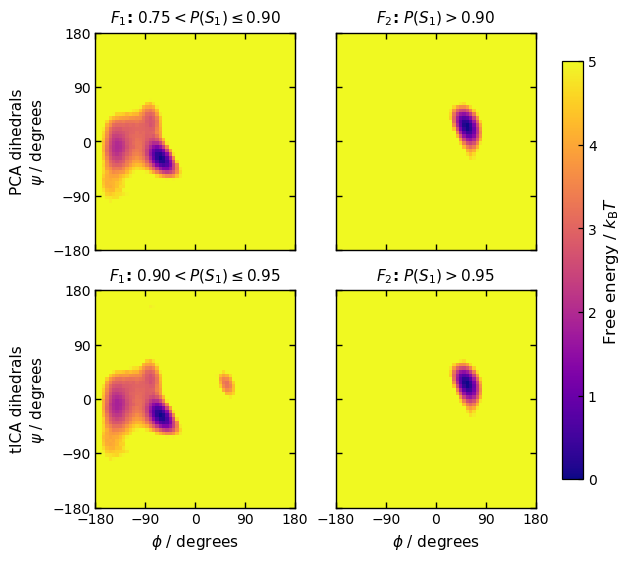

In [57]:
# ============================================================
# 3. Load backbone dihedral time series
# ============================================================
dihedral_timeseries = np.loadtxt(
    data_folder + "hp35.dihs",
    delimiter=" ",
    dtype=float
)

phis_timeseries = dihedral_timeseries[:, 0::2]
psis_timeseries = dihedral_timeseries[:, 1::2]

if len(dihedral_timeseries) != len(dtrajs_dict["pca_dihedrals"]):
    raise ValueError(
        "The dihedral and discrete trajectories do not have "
        "the same number of frames."
    )


# ============================================================
# 4. Select residues
# ============================================================
# Assumption:
# column 0 corresponds to residue 2
residues_to_plot = np.arange(3,4)

residue_names = [
    "Asp3"
]

residue_cols = [
    residue_number - 2
    for residue_number in residues_to_plot
]

if len(residue_names) != len(residue_cols):
    raise ValueError(
        "residue_names and residue_cols must have equal length."
    )


# ============================================================
# 5. Ramachandran free-energy helper
# ============================================================
def ramachandran_free_energy(
    phi,
    psi,
    bins=60,
    pseudocount=1e-12,
):
    """
    Compute F(phi, psi) = -log[P(phi, psi) / Pmax].

    The minimum free energy is shifted to zero.
    """
    phi = np.asarray(phi, dtype=float)
    psi = np.asarray(psi, dtype=float)

    valid = np.isfinite(phi) & np.isfinite(psi)
    phi = phi[valid]
    psi = psi[valid]

    if len(phi) == 0:
        raise ValueError(
            "No valid phi/psi observations were supplied."
        )

    H, phi_edges, psi_edges = np.histogram2d(
        phi,
        psi,
        bins=bins,
        range=[
            [-180, 180],
            [-180, 180],
        ],
        density=False,
    )

    P = H.astype(float) + pseudocount
    P /= P.sum()

    F = -np.log(P / P.max())

    # histogram2d returns H[x, y]; transpose for plotting
    F = F.T

    phi_centers = 0.5 * (
        phi_edges[:-1] + phi_edges[1:]
    )

    psi_centers = 0.5 * (
        psi_edges[:-1] + psi_edges[1:]
    )

    return phi_centers, psi_centers, F


# ============================================================
# 6. Plot
# ============================================================

# ============================================================
# 6. Plot: PCA on first row, tICA on second row
# ============================================================
panel_layout = [
    [
        ("PCA F1", macrostate_frames["PCA"]["F1"]),
        ("PCA F2", macrostate_frames["PCA"]["F2"]),
    ],
    [
        ("TICA F1", macrostate_frames["TICA"]["F1"]),
        ("TICA F2", macrostate_frames["TICA"]["F2"]),
    ],
]

panel_titles = {
    "PCA F1": r"$F_1$: $0.75 < P(S_1) \leq 0.90$",
    "PCA F2": r"$F_2$: $P(S_1) > 0.90$",
    "TICA F1": r"$F_1$: $0.90 < P(S_1) \leq 0.95$",
    "TICA F2": r"$F_2$: $P(S_1) > 0.95$",
}

row_labels = [
    "PCA dihedrals",
    "tICA dihedrals",
]

fig, axs = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(6.2, 5.5),
    sharex=True,
    sharey=True,
    constrained_layout=True,
    squeeze=False,
)


vmax = 5.0
norm = Normalize(vmin=0, vmax=vmax)

last_im = None
res_col = residue_cols[0]

for row in range(2):
    for col in range(2):

        state_name, frames = panel_layout[row][col]
        frames = np.asarray(frames, dtype=int)

        ax = axs[row, col]

        if len(frames) == 0:
            ax.text(
                0.5,
                0.5,
                "No frames",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )
            continue

        phi = phis_timeseries[frames, res_col]
        psi = psis_timeseries[frames, res_col]

        x, y, F = ramachandran_free_energy(
            phi,
            psi,
            bins=60,
        )

        F_plot = np.clip(F, 0, vmax)

        last_im = ax.pcolormesh(
            x,
            y,
            F_plot,
            shading="auto",
            cmap="plasma",
            norm=norm,
            rasterized=True,
        )

        ax.set_title(
            panel_titles[state_name],
            fontsize=11,
            fontweight="bold",
            pad=7,
        )

        if col == 0:
            ax.set_ylabel(
                row_labels[row] + "\n" + r"$\psi$ / degrees",
                fontsize=11,
            )

        if row == 1:
            ax.set_xlabel(
                r"$\phi$ / degrees",
                fontsize=11,
            )

        ax.set_xlim(-180, 180)
        ax.set_ylim(-180, 180)

        ax.set_xticks([-180, -90, 0, 90, 180])
        ax.set_yticks([-180, -90, 0, 90, 180])

        ax.tick_params(
            direction="in",
            length=4,
            width=1,
            top=True,
            right=True,
        )

        for spine in ax.spines.values():
            spine.set_linewidth(1)

if last_im is not None:
    cbar = fig.colorbar(
        last_im,
        ax=axs,
        location="right",
        shrink=0.88,
        pad=0.03,
    )

    cbar.set_label(
        r"Free energy / $k_{\mathrm{B}}T$",
        fontsize=12,
    )

    cbar.set_ticks([0, 1, 2, 3, 4, 5])

plt.savefig(
    "../output_figures/"
    "dihedrals_ramachandran_N1_N2_comparison.pdf",
    bbox_inches="tight",
)

plt.savefig(
    "../output_figures/"
    "dihedrals_ramachandran_N1_N2_comparison.png",
    dpi=600,
    bbox_inches="tight",
)

plt.show()

#### Save folded frames for later PyMol visualization

In [58]:
"""
filepath = "../intermediate_outputs/frame_lists/"
os.makedirs(filepath, exist_ok=True)

filename = os.path.join(filepath, "folded_core_consensus_frames.npy")
np.save(filename, consensus_frames)
"""

'\nfilepath = "../intermediate_outputs/frame_lists/"\nos.makedirs(filepath, exist_ok=True)\n\nfilename = os.path.join(filepath, "folded_core_consensus_frames.npy")\nnp.save(filename, consensus_frames)\n'

---
# Structural analysis of the folded basin (robust S1 core)

Define a *score* for contact importance that takes into consideration both the difference in the distance and the difference in the formation probability according to the cutoff.



$$
d^{\mathrm{robust}}_{ij}
=
\frac{
\mathrm{median}(r_{ij}^{\mathrm{other}})
-
\mathrm{median}(r_{ij}^{\mathrm{folded}})
}{
\mathrm{IQR}_{\mathrm{pooled}}
}
$$

So, in words we say that a contact is important if its distance distribution is
-  substantially shifted toward shorter distances in the folded basin.
- substantially more narrow in the folded basin.

Load descriptor timeseries

In [59]:
contacts_timeseries = np.loadtxt(data_folder + "hp35.crystaldists", delimiter = " ", dtype = float)
contacts_index = np.loadtxt(data_folder + "hp35.crystaldists.ndx", delimiter = " ", dtype = int)

contact_cutoff = 0.4 # nm

def summarize_contact_array(x, cutoff):
    return {
        "mean": np.mean(x),
        "std": np.std(x),
        "median": np.median(x),
        "q25": np.quantile(x, 0.25),
        "q75": np.quantile(x, 0.75),
        "iqr": np.quantile(x, 0.75) - np.quantile(x, 0.25),
        "formed_fraction": np.mean(x < cutoff),
    }

In [60]:

#macrostate_frames = {
#    "PCA F1": frames_dict["pca_dihedrals"]["F1"],
#    "PCA F2": frames_dict["pca_dihedrals"]["F2"],
#    "TICA F1": frames_dict["tica_dihedrals"]["F1"],
#    "TICA F2": frames_dict["tica_dihedrals"]["F2"],
#}

n_frames = contacts_timeseries.shape[0]
contact_rows = []

for model_name, model_dict in macrostate_frames.items():
    f1_frames = np.asarray(model_dict["F1"], dtype=int)
    f2_frames = np.asarray(model_dict["F2"], dtype=int)

    # Remove duplicates and invalid frame indices
    f1_frames = np.unique(
        f1_frames[(f1_frames >= 0) & (f1_frames < n_frames)]
    )
    f2_frames = np.unique(
        f2_frames[(f2_frames >= 0) & (f2_frames < n_frames)]
    )

    # Optional safeguard: remove overlapping frames
    overlap = np.intersect1d(f1_frames, f2_frames)

    if overlap.size > 0:
        print(
            f"Warning: removing {overlap.size} overlapping frames "
            f"from {model_name}."
        )
        f1_frames = np.setdiff1d(f1_frames, overlap)
        f2_frames = np.setdiff1d(f2_frames, overlap)

    f1_mask = np.zeros(n_frames, dtype=bool)
    f2_mask = np.zeros(n_frames, dtype=bool)

    f1_mask[f1_frames] = True
    f2_mask[f2_frames] = True

    if not np.any(f1_mask):
        raise ValueError(f"No valid F1 frames for {model_name}.")

    if not np.any(f2_mask):
        raise ValueError(f"No valid F2 frames for {model_name}.")

    for contact_column, pair in enumerate(contacts_index):

        res_i, res_j = map(int, pair)
        x = np.asarray(
            contacts_timeseries[:, contact_column],
            dtype=float,
        )

        f1_stats = summarize_contact_array(
            x[f1_mask],
            contact_cutoff,
        )

        f2_stats = summarize_contact_array(
            x[f2_mask],
            contact_cutoff,
        )

        pooled_iqr = 0.5 * (
            f1_stats["iqr"] + f2_stats["iqr"]
        )

        eps = 1e-12

        # Positive score means the distance is larger in F2 than F1
        robust_effect = (
            f2_stats["median"] - f1_stats["median"]
        ) / (pooled_iqr + eps)

        contact_rows.append({
            "model": model_name,
            "contact_column": contact_column,
            "contact": (res_i, res_j),
            "res_i": res_i,
            "res_j": res_j,

            "n_frames_F1": f1_mask.sum(),
            "n_frames_F2": f2_mask.sum(),

            "mean_F1": f1_stats["mean"],
            "std_F1": f1_stats["std"],
            "median_F1": f1_stats["median"],
            "q25_F1": f1_stats["q25"],
            "q75_F1": f1_stats["q75"],
            "iqr_F1": f1_stats["iqr"],
            "formed_fraction_F1": f1_stats["formed_fraction"],

            "mean_F2": f2_stats["mean"],
            "std_F2": f2_stats["std"],
            "median_F2": f2_stats["median"],
            "q25_F2": f2_stats["q25"],
            "q75_F2": f2_stats["q75"],
            "iqr_F2": f2_stats["iqr"],
            "formed_fraction_F2": f2_stats["formed_fraction"],

            "delta_mean_F2_minus_F1": (
                f2_stats["mean"] - f1_stats["mean"]
            ),

            "delta_fraction_F1_minus_F2": (
                f1_stats["formed_fraction"]
                - f2_stats["formed_fraction"]
            ),

            "pooled_iqr": pooled_iqr,
            "robust_distance_effect_size": robust_effect,
            "abs_robust_distance_effect_size": abs(robust_effect),
        })


contact_comparison_df = pd.DataFrame(contact_rows)

# Rank by the magnitude of the difference between F1 and F2
ranked_contacts_robust = (
    contact_comparison_df
    .sort_values(
        ["model", "abs_robust_distance_effect_size"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)

cols_to_show = [
    "model",
    "contact",
    "median_F1",
    "median_F2",
    "iqr_F1",
    "iqr_F2",
    "abs_robust_distance_effect_size",
    "formed_fraction_F1",
    "formed_fraction_F2",
    "delta_fraction_F1_minus_F2",
]

top_contacts_per_model = (
    ranked_contacts_robust
    .groupby("model", group_keys=False)
    .head(10)
)

display(top_contacts_per_model[cols_to_show])

,model,contact,median_F1,median_F2,iqr_F1,iqr_F2,abs_robust_distance_effect_size,formed_fraction_F1,formed_fraction_F2,delta_fraction_F1_minus_F2
0,PCA,"(2, 6)",0.416420,0.681570,0.307100,0.027630,1.584262,0.470689,0.000063,0.470626
1,PCA,"(1, 6)",0.876985,1.274780,0.636387,0.177300,0.977759,0.010010,0.000006,0.010004
2,PCA,"(1, 9)",1.081785,1.656200,0.998350,0.232160,0.933621,0.027150,0.000023,0.027127
3,PCA,"(1, 10)",1.261440,1.882585,1.070120,0.291542,0.912333,0.018445,0.000029,0.018416
4,PCA,"(1, 34)",1.300960,2.054050,1.386430,0.363322,0.860796,0.033473,0.000052,0.033420
5,PCA,"(1, 5)",0.688275,1.068280,0.630950,0.273760,0.840059,0.130920,0.000640,0.130279
6,PCA,"(1, 14)",0.664840,0.836180,0.371157,0.199570,0.600427,0.128755,0.001121,0.127633
7,PCA,"(5, 9)",0.375850,0.427760,0.146520,0.131650,0.373225,0.579383,0.378386,0.200996
8,PCA,"(6, 17)",0.446720,0.412100,0.129220,0.072070,0.343981,0.309576,0.401681,-0.092105
9,PCA,"(3, 14)",0.552040,0.471665,0.350110,0.147160,0.323265,0.306918,0.259372,0.047546


Distribution Plots

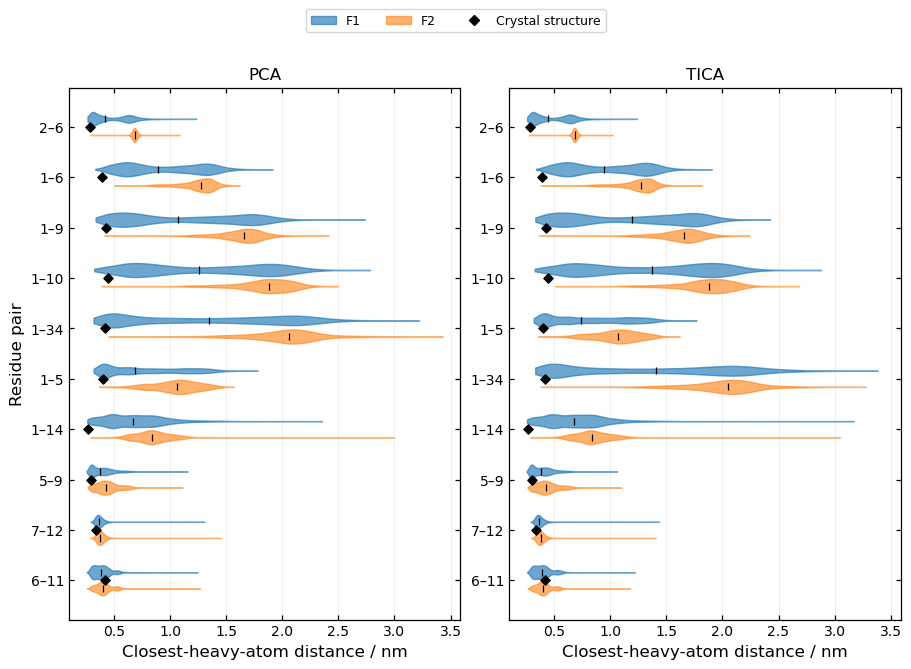

In [61]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------
n_plot = 10
n_frames = contacts_timeseries.shape[0]


reference_distance_map = np.load(
    "../intermediate_outputs/closest_heavy_dist_map.npy"
) * 0.1  # Å -> nm

rng = np.random.default_rng(42)
max_samples = 20_000


def subsample(values, max_samples=max_samples):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if values.size > max_samples:
        values = rng.choice(
            values,
            size=max_samples,
            replace=False,
        )

    return values


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, axs = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(9.0, 0.42 * n_plot + 1.8),
    sharex=True,
    constrained_layout=True,
)

offset = 0.16

for ax, model_name in zip(axs, macrostate_frames.keys()):

    # --------------------------------------------------------
    # Reconstruct F1 and F2 masks using the same logic
    # as in the DataFrame calculation
    # --------------------------------------------------------
    model_dict = macrostate_frames[model_name]

    f1_frames = np.asarray(
        model_dict["F1"],
        dtype=int,
    )

    f2_frames = np.asarray(
        model_dict["F2"],
        dtype=int,
    )

    f1_frames = np.unique(
        f1_frames[
            (f1_frames >= 0) &
            (f1_frames < n_frames)
        ]
    )

    f2_frames = np.unique(
        f2_frames[
            (f2_frames >= 0) &
            (f2_frames < n_frames)
        ]
    )

    overlap = np.intersect1d(
        f1_frames,
        f2_frames,
    )

    if overlap.size > 0:
        f1_frames = np.setdiff1d(
            f1_frames,
            overlap,
        )
        f2_frames = np.setdiff1d(
            f2_frames,
            overlap,
        )

    f1_mask = np.zeros(n_frames, dtype=bool)
    f2_mask = np.zeros(n_frames, dtype=bool)

    f1_mask[f1_frames] = True
    f2_mask[f2_frames] = True

    if not np.any(f1_mask):
        raise ValueError(
            f"No valid F1 frames for {model_name}."
        )

    if not np.any(f2_mask):
        raise ValueError(
            f"No valid F2 frames for {model_name}."
        )

    # --------------------------------------------------------
    # Select top contacts for this model
    # --------------------------------------------------------
    top_contacts = (
        ranked_contacts_robust
        .loc[
            ranked_contacts_robust["model"] == model_name
        ]
        .sort_values(
            "robust_distance_effect_size",
            ascending=False,
        )
        .head(n_plot)
        .copy()
    )

    if top_contacts.empty:
        raise ValueError(
            f"No ranked contacts found for {model_name}. "
            f"Available model labels: "
            f"{ranked_contacts_robust['model'].unique().tolist()}"
        )

    contact_columns = top_contacts[
        "contact_column"
    ].to_numpy(dtype=int)

    contact_pairs = top_contacts[
        ["res_i", "res_j"]
    ].to_numpy(dtype=int)

    contact_labels = [
        f"{res_i}–{res_j}"
        for res_i, res_j in contact_pairs
    ]

    # --------------------------------------------------------
    # Extract F1 and F2 distributions
    # --------------------------------------------------------
    f1_data = []
    f2_data = []
    valid_rows = []

    for row_index, contact_column in enumerate(contact_columns):

        values_f1 = subsample(
            contacts_timeseries[
                f1_mask,
                contact_column,
            ]
        )

        values_f2 = subsample(
            contacts_timeseries[
                f2_mask,
                contact_column,
            ]
        )

        # Matplotlib violinplot cannot accept empty arrays
        if values_f1.size == 0 or values_f2.size == 0:
            continue

        f1_data.append(values_f1)
        f2_data.append(values_f2)
        valid_rows.append(row_index)

    if len(valid_rows) == 0:
        raise ValueError(
            f"No selected contacts have finite values "
            f"in both F1 and F2 for {model_name}."
        )

    # Keep labels and reference distances aligned with valid data
    top_contacts = (
        top_contacts
        .iloc[valid_rows]
        .reset_index(drop=True)
    )

    contact_pairs = top_contacts[
        ["res_i", "res_j"]
    ].to_numpy(dtype=int)

    contact_labels = [
        f"{res_i}–{res_j}"
        for res_i, res_j in contact_pairs
    ]

    reference_contact_distances = np.array([
        reference_distance_map[
            res_i - 1,
            res_j - 1,
        ]
        for res_i, res_j in contact_pairs
    ])

    positions = np.arange(len(top_contacts))

    # --------------------------------------------------------
    # Violin plots
    # --------------------------------------------------------
    vp_f1 = ax.violinplot(
        f1_data,
        positions=positions - offset,
        vert=False,
        widths=0.28,
        showmeans=False,
        showmedians=True,
        showextrema=False,
    )

    vp_f2 = ax.violinplot(
        f2_data,
        positions=positions + offset,
        vert=False,
        widths=0.28,
        showmeans=False,
        showmedians=True,
        showextrema=False,
    )

    for body in vp_f1["bodies"]:
        body.set_facecolor("tab:blue")
        body.set_edgecolor("tab:blue")
        body.set_alpha(0.65)

    for body in vp_f2["bodies"]:
        body.set_facecolor("tab:orange")
        body.set_edgecolor("tab:orange")
        body.set_alpha(0.60)

    vp_f1["cmedians"].set_color("black")
    vp_f1["cmedians"].set_linewidth(0.9)

    vp_f2["cmedians"].set_color("black")
    vp_f2["cmedians"].set_linewidth(0.9)

    # Crystal structure reference
    ax.scatter(
        reference_contact_distances,
        positions,
        marker="D",
        s=22,
        color="black",
        zorder=5,
    )

    # --------------------------------------------------------
    # Axes
    # --------------------------------------------------------
    ax.set_yticks(positions)
    ax.set_yticklabels(contact_labels)
    ax.invert_yaxis()

    ax.set_title(model_name)
    ax.set_xlabel(
        "Closest-heavy-atom distance / nm"
    )

    ax.grid(
        axis="x",
        alpha=0.2,
    )

axs[0].set_ylabel("Residue pair")

# ------------------------------------------------------------
# Shared legend
# ------------------------------------------------------------
legend_handles = [
    Patch(
        facecolor="tab:blue",
        edgecolor="tab:blue",
        alpha=0.65,
        label="F1",
    ),
    Patch(
        facecolor="tab:orange",
        edgecolor="tab:orange",
        alpha=0.60,
        label="F2",
    ),
    Line2D(
        [0],
        [0],
        marker="D",
        linestyle="none",
        color="black",
        markersize=5,
        label="Crystal structure",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.1),
    ncols=3,
    frameon=True,
)

plt.savefig(
    "../output_figures/F1_F2_contact_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Dwell-time distributions in the folded sub-basins F1 and F2

In the first part of the notebook the folded macrostate `S1` was split into
two sub-peaks, `F1` and `F2`, on the basis of the PCCA membership probability
`P(S1)` (the microstates belonging to each are stored in `micro_dict`, and are
defined only for the two dihedral models).

Here I turn each microstate trajectory into a discrete `F1 / F2 / other`
trajectory (`other` = every frame not assigned to F1 or F2, i.e. the unfolded
basin plus the ambiguous folded microstates), apply temporal coring to remove
sub-lag flickering, and compute the **distribution of dwell times** spent in
`F1` and `F2` before leaving the sub-basin.

In [62]:
# ============================================================
# Dwell times in the folded sub-basins F1 and F2
# ============================================================
# F1 and F2 are defined (in `micro_dict`) only for the dihedral models.
# State encoding is chosen so that the numeric order matches increasing
# "foldedness": other (0) -> F1 (1) -> F2 (2).
STATE_OTHER, STATE_F1, STATE_F2 = 0, 1, 2
state_code = {"F1": STATE_F1, "F2": STATE_F2, "other": STATE_OTHER}

dihedral_models = [name for name in trajectories_labels if name in micro_dict]


def core_trajectory(labels, min_core_frames):
    """
    Temporal coring for a discrete trajectory with an arbitrary set of integer
    labels (generalisation of the two-state coring used previously).

    A transition to a new state is accepted only if the trajectory then remains
    continuously in that new state for at least `min_core_frames` frames;
    shorter excursions are treated as noise and re-assigned to the current core
    state.
    """
    labels = np.asarray(labels, dtype=int)
    if labels.ndim != 1:
        raise ValueError("labels must be a one-dimensional trajectory.")
    if len(labels) == 0:
        return labels.copy()

    min_core_frames = max(1, int(min_core_frames))
    cored = np.full(len(labels), labels[0], dtype=int)

    current_state = labels[0]
    candidate_state = None
    candidate_start = None
    candidate_length = 0

    for i in range(1, len(labels)):
        observed = labels[i]

        if observed == current_state:
            # returned to the current core before completing a transition
            candidate_state = None
            candidate_start = None
            candidate_length = 0
            cored[i] = current_state
            continue

        if observed == candidate_state:
            candidate_length += 1
        else:
            # start testing a different candidate state
            candidate_state = observed
            candidate_start = i
            candidate_length = 1

        if candidate_length >= min_core_frames:
            # accept the transition retroactively from its first frame
            current_state = candidate_state
            cored[candidate_start:i + 1] = current_state
            candidate_state = None
            candidate_start = None
            candidate_length = 0
        else:
            cored[i] = current_state

    return cored


def dwell_times(cored_traj, state, time_step_micros):
    """
    Durations (in microseconds) of continuous residence in `state`, extracted
    from a (cored) discrete trajectory. Each returned value is one uninterrupted
    visit to the state.
    """
    traj = np.asarray(cored_traj, dtype=int)
    if len(traj) == 0:
        return np.asarray([], dtype=float)

    change_points = np.where(np.diff(traj) != 0)[0] + 1
    starts = np.r_[0, change_points]
    ends = np.r_[change_points, len(traj)]

    times = [
        (end - start) * time_step_micros
        for start, end in zip(starts, ends)
        if traj[start] == state
    ]
    return np.asarray(times, dtype=float)


# ------------------------------------------------------------
# Coring window: same convention as before, one MSM lag step
# ------------------------------------------------------------
min_core_markov_steps = 1
min_core_mus = min_core_markov_steps * MSM_LAG_NS / 1000
min_core_frames = max(1, int(np.ceil(min_core_mus / time_step_micros)))

print("Minimum core time:", min_core_mus, "µs")
print("Minimum core frames:", min_core_frames)


# ------------------------------------------------------------
# Build F1 / F2 / other trajectories and extract dwell times
# ------------------------------------------------------------
f1f2_raw_dict = {}
f1f2_cored_dict = {}
dwell_F1_dict = {}
dwell_F2_dict = {}

for name in dihedral_models:
    dtraj = np.asarray(dtrajs_dict[name])

    raw = np.full(len(dtraj), STATE_OTHER, dtype=int)
    raw[np.isin(dtraj, micro_dict[name]["F1"])] = STATE_F1
    raw[np.isin(dtraj, micro_dict[name]["F2"])] = STATE_F2

    cored = core_trajectory(raw, min_core_frames=min_core_frames)

    f1f2_raw_dict[name] = raw
    f1f2_cored_dict[name] = cored

    dwell_F1_dict[name] = dwell_times(cored, STATE_F1, time_step_micros)
    dwell_F2_dict[name] = dwell_times(cored, STATE_F2, time_step_micros)

    def _fmt(a):
        return (np.mean(a), np.median(a)) if len(a) else (np.nan, np.nan)

    m1, md1 = _fmt(dwell_F1_dict[name])
    m2, md2 = _fmt(dwell_F2_dict[name])
    print(
        f"\n{name}:"
        f"\n  F1: {len(dwell_F1_dict[name]):4d} visits | "
        f"mean {m1:.3f} µs | median {md1:.3f} µs"
        f"\n  F2: {len(dwell_F2_dict[name]):4d} visits | "
        f"mean {m2:.3f} µs | median {md2:.3f} µs"
    )


Minimum core time: 0.05 µs
Minimum core frames: 251

tica_dihedrals:
  F1:  177 visits | mean 0.603 µs | median 0.463 µs
  F2:  145 visits | mean 0.658 µs | median 0.435 µs

pca_dihedrals:
  F1:  195 visits | mean 0.529 µs | median 0.412 µs
  F2:  145 visits | mean 0.676 µs | median 0.480 µs


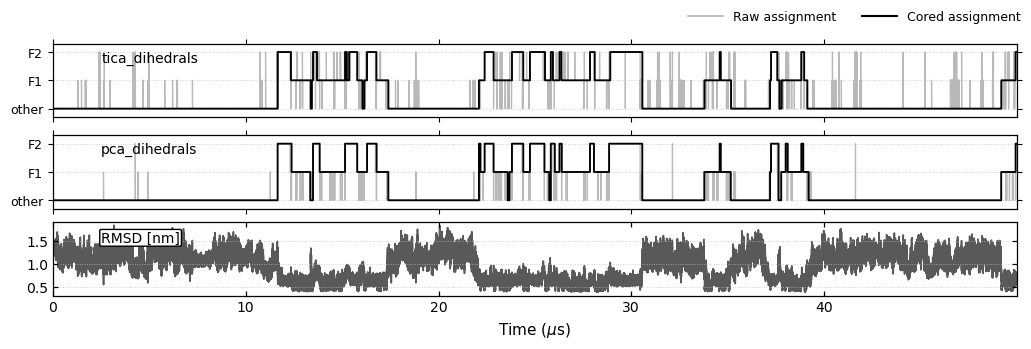

In [63]:
# ============================================================
# Raw vs cored F1/F2/other trajectory over a time window
# ============================================================
from matplotlib.lines import Line2D

tmin_mus = 0
tmax_mus = 50

n_total = len(f1f2_raw_dict[dihedral_models[0]])
frame_min = max(0, int(np.floor(tmin_mus / time_step_micros)))
frame_max = min(n_total, int(np.ceil(tmax_mus / time_step_micros)))
if frame_max <= frame_min:
    raise ValueError("The selected time window contains no trajectory frames.")

time_mus = np.arange(frame_min, frame_max) * time_step_micros

fig, axs = plt.subplots(
    nrows=len(dihedral_models) + 1,
    ncols=1,
    figsize=(10.2, 3.4),
    sharex=True,
    constrained_layout=True,
)
axs = np.atleast_1d(axs)

for ax, name in zip(axs, dihedral_models):
    raw = np.asarray(f1f2_raw_dict[name][frame_min:frame_max])
    cored = np.asarray(f1f2_cored_dict[name][frame_min:frame_max])

    ax.step(time_mus, raw, where="post",
            color="0.68", linewidth=0.9, alpha=0.85, zorder=1)
    ax.step(time_mus, cored, where="post",
            color="black", linewidth=1.35, zorder=2)

    ax.text(0.05, 0.90, name, transform=ax.transAxes,
            ha="left", va="top", fontsize=10)

    ax.set_yticks([STATE_OTHER, STATE_F1, STATE_F2])
    ax.set_yticklabels(["other", "F1", "F2"])
    ax.set_ylim(-0.3, 2.3)
    ax.grid(axis="y", linestyle=":", linewidth=0.65,
            color="0.75", alpha=0.8, zorder=0)
    ax.tick_params(axis="both", which="major", labelsize=9,
                   direction="out", length=3.5, width=0.8)

# RMSD reference panel
axs[-1].plot(time_mus, rmsd[frame_min:frame_max],
             color="0.35", linewidth=1.2, zorder=0)
axs[-1].text(0.05, 0.88, "RMSD [nm]", transform=axs[-1].transAxes,
             ha="left", va="top", fontsize=10,
             bbox=dict(facecolor="white", edgecolor="black",
                       boxstyle="round,pad=0.1"))
axs[-1].grid(which="major", axis="y", linestyle=":", linewidth=0.65,
             color="0.75", alpha=0.8, zorder=0)
axs[-1].set_xlim(tmin_mus, min(tmax_mus, time_mus[-1]))
axs[-1].set_xlabel(r"Time ($\mu$s)", fontsize=11)

legend_handles = [
    Line2D([0], [0], color="0.68", linewidth=1.1, label="Raw assignment"),
    Line2D([0], [0], color="black", linewidth=1.5, label="Cored assignment"),
]
fig.legend(handles=legend_handles, loc="outside upper right",
           frameon=False, fontsize=9, handlelength=2.8, ncols=2)

fig.savefig("../output_figures/f1_f2_raw_vs_cored_assignments.pdf",
            bbox_inches="tight")
plt.show()


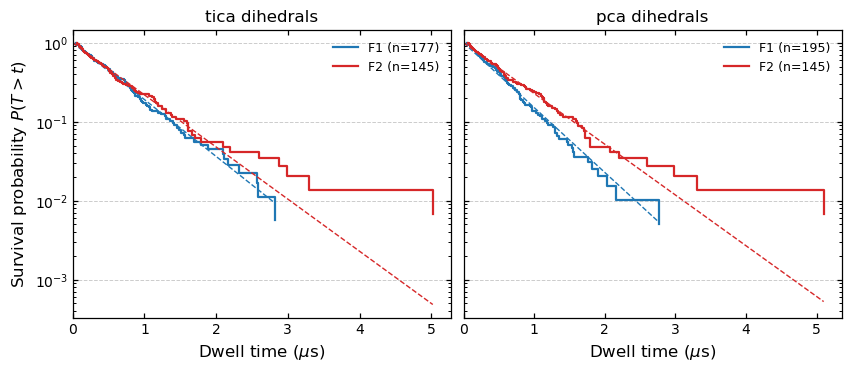

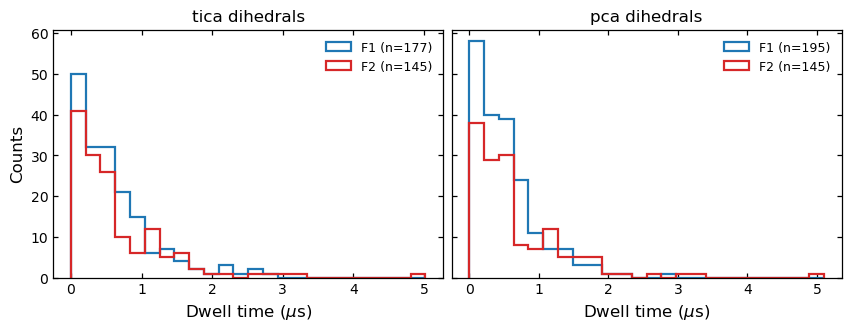

\begin{table}
\caption{Dwell times in the folded sub-basins $F_1$ and $F_2$, computed from the cored microstate trajectory of each dihedral model. $N_{\mathrm{visits}}$ is the number of continuous visits to the sub-basin, and the population is the fraction of cored frames assigned to it.}
\label{tab:f1_f2_dwell_times}
\begin{tabular}{llrrrr}
\toprule
Model & State & $N_{\mathrm{visits}}$ & Mean [$\mu$s] & Median [$\mu$s] & Population \\
\midrule
tica\_dihedrals & F1 & 177 & 0.603 & 0.463 & 0.350 \\
tica\_dihedrals & F2 & 145 & 0.658 & 0.435 & 0.313 \\
pca\_dihedrals & F1 & 195 & 0.529 & 0.412 & 0.338 \\
pca\_dihedrals & F2 & 145 & 0.676 & 0.480 & 0.321 \\
\bottomrule
\end{tabular}
\end{table}



,Model,State,$N_{\mathrm{visits}}$,Mean [$\mu$s],Median [$\mu$s],Population
0,tica\_dihedrals,F1,177,0.603354,0.463084,0.350143
1,tica\_dihedrals,F2,145,0.657984,0.435103,0.312812
2,pca\_dihedrals,F1,195,0.528919,0.412319,0.338161
3,pca\_dihedrals,F2,145,0.675933,0.480072,0.321345


In [64]:
# ============================================================
# Dwell-time distributions in F1 and F2
# ============================================================
dwell_by_state = {"F1": dwell_F1_dict, "F2": dwell_F2_dict}
state_colors = {"F1": "tab:blue", "F2": "tab:red"}

# ------------------------------------------------------------
# Survival curves P(T > t), one panel per dihedral model.
# Dashed lines are single-exponential references from the sample mean.
# ------------------------------------------------------------
fig, axs = plt.subplots(
    1, len(dihedral_models),
    figsize=(4.2 * len(dihedral_models), 3.6),
    sharey=True,
    constrained_layout=True,
)
axs = np.atleast_1d(axs)

for ax, name in zip(axs, dihedral_models):
    t_max = 0.0
    for state in ("F1", "F2"):
        times = np.sort(np.asarray(dwell_by_state[state][name], dtype=float))
        if len(times) == 0:
            continue
        t_max = max(t_max, times.max())

        # empirical survival probability P(T > t)
        survival = 1.0 - np.arange(1, len(times) + 1) / (len(times) + 1)
        ax.step(times, survival, where="post", linewidth=1.6,
                color=state_colors[state], label=f"{state} (n={len(times)})")

        # exponential reference using the sample mean
        t_fit = np.linspace(0, times.max(), 300)
        ax.plot(t_fit, np.exp(-t_fit / times.mean()),
                linestyle="--", linewidth=1.0, color=state_colors[state])

    ax.set_yscale("log")
    ax.set_title(name.replace("_", " "))
    ax.set_xlabel(r"Dwell time ($\mu$s)")
    ax.set_xlim(0, t_max * 1.05 if t_max > 0 else 1.0)
    ax.grid(which="major", axis="y", linestyle="--", linewidth=0.7,
            color="0.75", alpha=0.8, zorder=0)
    ax.legend(frameon=False)

axs[0].set_ylabel(r"Survival probability $P(T > t)$")

fig.savefig("../output_figures/f1_f2_dwell_time_survival.pdf",
            bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# Complementary view: dwell-time histograms
# ------------------------------------------------------------
fig, axs = plt.subplots(
    1, len(dihedral_models),
    figsize=(4.2 * len(dihedral_models), 3.2),
    sharey=True,
    constrained_layout=True,
)
axs = np.atleast_1d(axs)

for ax, name in zip(axs, dihedral_models):
    all_times = np.concatenate([
        np.asarray(dwell_by_state[s][name], dtype=float) for s in ("F1", "F2")
    ]) if (len(dwell_F1_dict[name]) + len(dwell_F2_dict[name])) else np.array([0.0])
    bins = np.linspace(0, all_times.max() if all_times.size else 1.0, 25)

    for state in ("F1", "F2"):
        times = np.asarray(dwell_by_state[state][name], dtype=float)
        if len(times) == 0:
            continue
        ax.hist(times, bins=bins, histtype="step", linewidth=1.6,
                color=state_colors[state], label=f"{state} (n={len(times)})")

    ax.set_title(name.replace("_", " "))
    ax.set_xlabel(r"Dwell time ($\mu$s)")
    ax.legend(frameon=False)

axs[0].set_ylabel("Counts")

fig.savefig("../output_figures/f1_f2_dwell_time_histograms.pdf",
            bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# Summary table of dwell times
# ------------------------------------------------------------
rows = []
for name in dihedral_models:
    n_frames = len(f1f2_cored_dict[name])
    for state in ("F1", "F2"):
        times = np.asarray(dwell_by_state[state][name], dtype=float)
        population = np.mean(f1f2_cored_dict[name] == state_code[state])
        rows.append({
            "Model": name.replace("_", r"\_"),
            "State": state,
            r"$N_{\mathrm{visits}}$": len(times),
            r"Mean [$\mu$s]": times.mean() if len(times) else np.nan,
            r"Median [$\mu$s]": np.median(times) if len(times) else np.nan,
            "Population": population,
        })

dwell_df = pd.DataFrame(rows)

latex_table = dwell_df.to_latex(
    index=False,
    escape=False,
    float_format="%.3f",
    caption=(
        r"Dwell times in the folded sub-basins $F_1$ and $F_2$, computed from "
        r"the cored microstate trajectory of each dihedral model. "
        r"$N_{\mathrm{visits}}$ is the number of continuous visits to the "
        r"sub-basin, and the population is the fraction of cored frames "
        r"assigned to it."
    ),
    label="tab:f1_f2_dwell_times",
)
print(latex_table)

dwell_df
